# Resolución, Muestreo y Cuantización

Grupo:
- 190242 Thiago Puyelli
- 174264 Matias Herrneder
- 190306 Valentín J. Romero Monteagudo

## 0. Imports y configuración

In [27]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Carpetas del proyecto
DIR_IMAGENES = "imagenes"
DIR_SALIDAS  = "salidas"
os.makedirs(DIR_IMAGENES, exist_ok=True)
os.makedirs(DIR_SALIDAS,  exist_ok=True)

# Que las imagenes se vean sin interpolación (para apreciar el pixelado real)
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["figure.dpi"] = 110

print("Todo listo.")

Todo listo.


## 1. Cargar la imagen y extraer sus datos

In [28]:
def generar_imagen(lado=500):
    """Imagen sintética: franjas, tablero y ruido de alto contraste."""
    y, x = np.mgrid[0:lado, 0:lado]
    franjas   = (np.sin(x / 3.0) * 127 + 128).astype(np.uint8)
    tablero   = (((x // 12) + (y // 12)) % 2 * 255).astype(np.uint8)
    diagonal  = ((x + y) % 64 < 32).astype(np.uint8) * 255
    r = franjas
    g = tablero
    b = np.clip(diagonal.astype(int) + (x % 97), 0, 255).astype(np.uint8)
    return Image.fromarray(np.dstack([r, g, b]), mode="RGB")

NOMBRE_SINTETICA = "sintetica.png"

EXTS = ("*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff", "*.webp", "*.gif")
encontradas = []
for e in EXTS:
    encontradas += glob.glob(os.path.join(DIR_IMAGENES, e))
    encontradas += glob.glob(os.path.join(DIR_IMAGENES, e.upper()))

encontradas = sorted(p for p in set(encontradas)
                     if os.path.basename(p) != NOMBRE_SINTETICA)

if encontradas:
    RUTA_IMAGEN = encontradas[0]
    pil_img = Image.open(RUTA_IMAGEN)
    print(f"Imagen cargada desde: {RUTA_IMAGEN}")
else:
    RUTA_IMAGEN = os.path.join(DIR_IMAGENES, NOMBRE_SINTETICA)
    pil_img = generar_imagen(500)
    pil_img.save(RUTA_IMAGEN)

Imagen cargada desde: imagenes/LinkedIn_Headquarters_Mountain_View.jpg


In [29]:
# --- Metadatos con PIL (antes de convertir) ---
print("=" * 50)
print("DATOS DE LA IMAGEN (PIL)")
print("=" * 50)
print(f"Archivo            : {RUTA_IMAGEN}")
print(f"Formato            : {pil_img.format}")
print(f"Modo de color      : {pil_img.mode}")
print(f"Tamaño (ancho x alto): {pil_img.size[0]} x {pil_img.size[1]} px")
print(f"Cantidad de bandas : {len(pil_img.getbands())}  {pil_img.getbands()}")

dpi = pil_img.info.get("dpi")
print(f"Resolución (DPI)   : {dpi if dpi else 'no especificada en el archivo'}")

if os.path.exists(RUTA_IMAGEN):
    tam_bytes = os.path.getsize(RUTA_IMAGEN)
    print(f"Tamaño en disco    : {tam_bytes:,} bytes  ({tam_bytes/1024:.1f} KB)")

DATOS DE LA IMAGEN (PIL)
Archivo            : imagenes/LinkedIn_Headquarters_Mountain_View.jpg
Formato            : JPEG
Modo de color      : RGB
Tamaño (ancho x alto): 3792 x 2528 px
Cantidad de bandas : 3  ('R', 'G', 'B')
Resolución (DPI)   : (300, 300)
Tamaño en disco    : 5,671,248 bytes  (5538.3 KB)


In [30]:
# --- Pasamos a arreglo de numpy para analizar los valores de los píxeles ---
img = np.asarray(pil_img)

print("=" * 50)
print("DATOS DEL ARREGLO (NumPy)")
print("=" * 50)
print(f"shape (alto, ancho, canales): {img.shape}")
print(f"Tipo de dato (dtype)        : {img.dtype}")
print(f"Bits por canal              : {img.dtype.itemsize * 8} bits")
print(f"Total de píxeles            : {img.shape[0] * img.shape[1]:,}")
print(f"Valor mínimo / máximo       : {img.min()} / {img.max()}")
print(f"Media / desvío estándar     : {img.mean():.2f} / {img.std():.2f}")
n_niveles = len(np.unique(img))
print(f"Niveles distintos presentes : {n_niveles} (de 256 posibles en 8 bits)")

DATOS DEL ARREGLO (NumPy)
shape (alto, ancho, canales): (2528, 3792, 3)
Tipo de dato (dtype)        : uint8
Bits por canal              : 8 bits
Total de píxeles            : 9,586,176
Valor mínimo / máximo       : 0 / 255
Media / desvío estándar     : 105.88 / 68.71
Niveles distintos presentes : 256 (de 256 posibles en 8 bits)


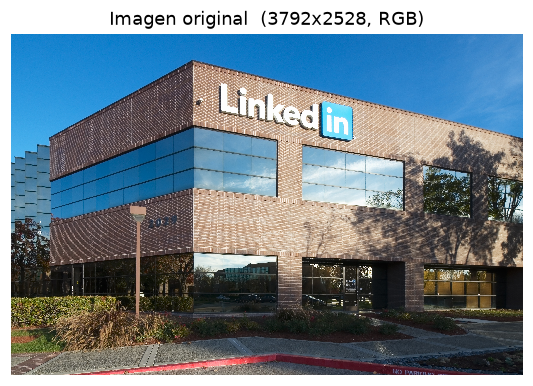

In [31]:
# --- Mostramos la imagen ---
plt.figure(figsize=(6, 6))
if img.ndim == 2:
    plt.imshow(img, cmap="gray", vmin=0, vmax=255)
else:
    plt.imshow(img)
plt.title(f"Imagen original  ({pil_img.size[0]}x{pil_img.size[1]}, {pil_img.mode})")
plt.axis("off")
plt.show()

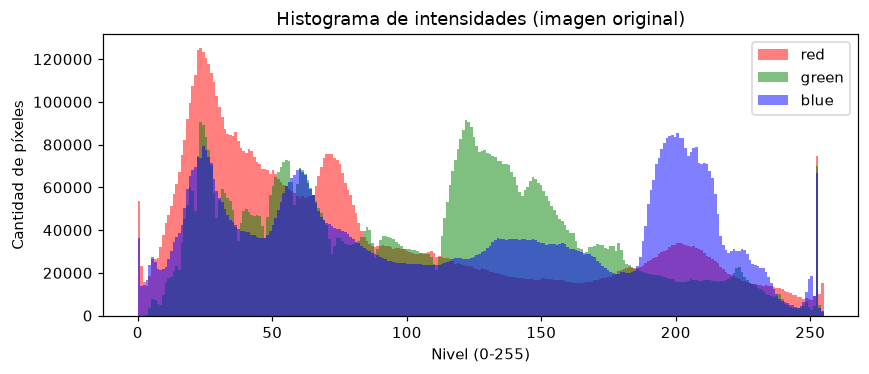

In [32]:
# --- Histograma: cómo se reparten los niveles de intensidad ---
plt.figure(figsize=(8, 3.5))
if img.ndim == 2:
    plt.hist(img.ravel(), bins=256, range=(0, 255), color="gray")
else:
    for i, c in enumerate(["red", "green", "blue"][:img.shape[2]]):
        plt.hist(img[:, :, i].ravel(), bins=256, range=(0, 255),
                 color=c, alpha=0.5, label=c)
    plt.legend()
plt.title("Histograma de intensidades (imagen original)")
plt.xlabel("Nivel (0-255)"); plt.ylabel("Cantidad de píxeles")
plt.tight_layout(); plt.show()

## 1.1 Las 4 resoluciones de la imagen



In [33]:
alto, ancho = img.shape[:2]
bandas = img.shape[2] if img.ndim == 3 else 1
bits   = img.dtype.itemsize * 8
dpi    = pil_img.info.get("dpi")
tomas  = getattr(pil_img, "n_frames", 1)

print("=" * 60)
print("LAS 4 RESOLUCIONES DE LA IMAGEN")
print("=" * 60)

# 1) ESPACIAL: cuanto detalle geometrico entra en la grilla de pixeles
print(f"1) ESPACIAL     : {ancho} x {alto} px  ({ancho * alto:,} pixeles)")
if dpi and dpi[0]:
    print(f"   {dpi[0]:.0f} DPI -> impresa, cada pixel mide {25.4 / dpi[0]:.3f} mm")
else:
    print("   sin DPI en el archivo -> el pixel no tiene un tamaño fisico definido")

# 2) TEMPORAL: cada cuanto se repite la toma (hace falta una serie de imagenes)
print(f"\n2) TEMPORAL     : {tomas} toma(s) en el archivo")
if tomas == 1:
    print("   una sola captura -> no hay resolucion temporal que medir")
else:
    print("   secuencia -> la resolucion temporal es el intervalo entre tomas")

# 3) FRECUENCIAL: que frecuencias de luz mide (bandas) y que frecuencias
#    espaciales puede representar la grilla (limite de Nyquist = 0.5 ciclos/px)
print(f"\n3) FRECUENCIAL  : {bandas} banda(s) {pil_img.getbands()}  <- rangos del espectro")
gris = img.mean(axis=2) if img.ndim == 3 else img.astype(np.float32)
energia = np.abs(np.fft.fft2(gris - gris.mean())) ** 2
radio = np.hypot(np.fft.fftfreq(ancho)[None, :], np.fft.fftfreq(alto)[:, None])
f_media = (energia * radio).sum() / energia.sum()   # centroide espectral, en ciclos/px
print("   Nyquist = 0.500 ciclos/px -> el detalle mas fino representable mide 2 px")
print(f"   frecuencia media de la imagen = {f_media:.3f} ciclos/px  (~{1 / f_media:.1f} px por ciclo)")

# 4) RADIOMETRICA: cuantos niveles de intensidad admite cada pixel
print(f"\n4) RADIOMETRICA : {bits} bits por canal -> {2 ** bits} niveles posibles (0-{2 ** bits - 1})")
print(f"   niveles realmente presentes: {len(np.unique(img))}")


LAS 4 RESOLUCIONES DE LA IMAGEN
1) ESPACIAL     : 3792 x 2528 px  (9,586,176 pixeles)
   300 DPI -> impresa, cada pixel mide 0.085 mm

2) TEMPORAL     : 1 toma(s) en el archivo
   una sola captura -> no hay resolucion temporal que medir

3) FRECUENCIAL  : 3 banda(s) ('R', 'G', 'B')  <- rangos del espectro
   Nyquist = 0.500 ciclos/px -> el detalle mas fino representable mide 2 px
   frecuencia media de la imagen = 0.018 ciclos/px  (~54.2 px por ciclo)

4) RADIOMETRICA : 8 bits por canal -> 256 niveles posibles (0-255)
   niveles realmente presentes: 256


## 2. Reducción de resolución **espacial** (pixelado)

**mantener el tamaño en píxeles** (sigue siendo 500×500) pero agrupar la imagen en **bloques de f×f píxeles** y reemplazar cada bloque por **un único valor** (el promedio del bloque). Así el "píxel visible" se hace más grande.


La imagen resultante tiene las **mismas dimensiones**, pero mucho menos detalle espacial.

In [34]:
def bloque_desde_escala(escala):
    """Escala en % de detalle espacial por eje -> lado del bloque f.
    100% -> 1 (original) | 50% -> 2 | 25% -> 4 | 12.5% -> 8 | 2% -> 50
    """
    return max(1, int(round(100.0 / escala)))


def reducir_espacial(imagen, escala):
    """Conserva 'escala' % del detalle espacial en cada eje.
    Agrupa la imagen en bloques de f x f (f = 100/escala), promedia cada bloque
    y lo re-expande al tamaño original: mide (casi) lo mismo pero se ve pixelada.
    """
    f = bloque_desde_escala(escala)
    a = imagen.astype(np.float32)
    h, w = a.shape[:2]
    hh, ww = (h // f) * f, (w // f) * f
    a = a[:hh, :ww]

    if a.ndim == 2:                            # escala de grises
        bloques = a.reshape(hh // f, f, ww // f, f).mean(axis=(1, 3))
    else:                                      # color
        c = a.shape[2]
        bloques = a.reshape(hh // f, f, ww // f, f, c).mean(axis=(1, 3))
    exp = np.repeat(np.repeat(bloques, f, axis=0), f, axis=1)

    return np.clip(exp, 0, 255).astype(np.uint8)


for e in [100, 50, 25, 12.5, 2]:
    f = bloque_desde_escala(e)
    print(f"escala {e:5g}%  ->  bloque {f}x{f}  ({f*f} px = 1 valor)")

prueba = reducir_espacial(img, 50)
print("\nOriginal:", img.shape, "->  escala 50%:", prueba.shape)

escala   100%  ->  bloque 1x1  (1 px = 1 valor)
escala    50%  ->  bloque 2x2  (4 px = 1 valor)
escala    25%  ->  bloque 4x4  (16 px = 1 valor)
escala  12.5%  ->  bloque 8x8  (64 px = 1 valor)
escala     2%  ->  bloque 50x50  (2500 px = 1 valor)

Original: (2528, 3792, 3) ->  escala 50%: (2528, 3792, 3)


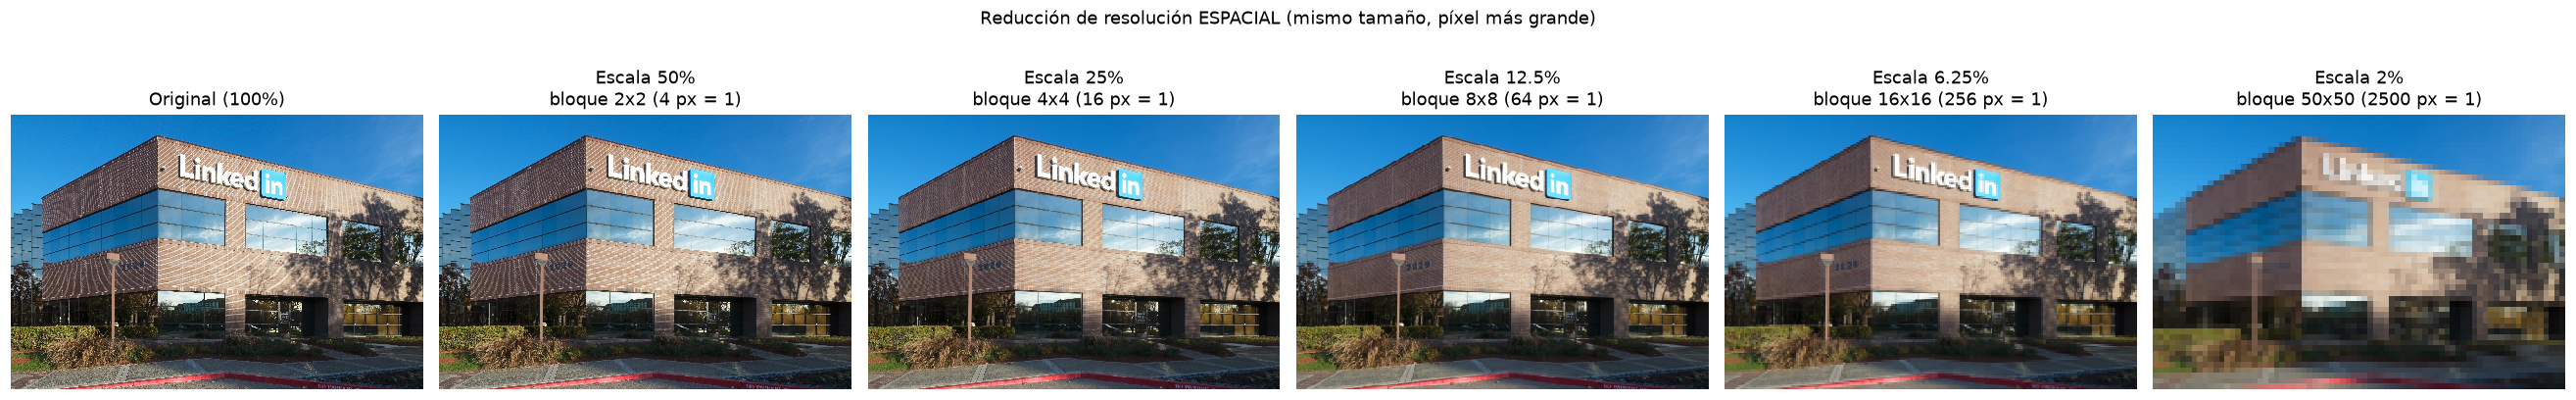

In [35]:
# Comparación a distintas escalas (% de detalle espacial que se conserva por eje)
ESCALAS_ESPACIAL = [100, 50, 25, 12.5, 6.25, 2]

fig, axes = plt.subplots(1, len(ESCALAS_ESPACIAL), figsize=(4 * len(ESCALAS_ESPACIAL), 4))
for ax, e in zip(axes, ESCALAS_ESPACIAL):
    f = bloque_desde_escala(e)
    red = reducir_espacial(img, e)
    if red.ndim == 2:
        ax.imshow(red, cmap="gray", vmin=0, vmax=255)
    else:
        ax.imshow(red)
    titulo = "Original (100%)" if f == 1 else f"Escala {e:g}%\nbloque {f}x{f} ({f*f} px = 1)"
    ax.set_title(titulo); ax.axis("off")
plt.suptitle("Reducción de resolución ESPACIAL (mismo tamaño, píxel más grande)", y=1.02)
plt.tight_layout(); plt.show()

## 3. Reducción de resolución **radiométrica** (niveles / bits)

La resolución radiométrica es **cuántos niveles de intensidad** puede tener cada píxel. 

Cuantizamos cada píxel al nivel más cercano de la nueva grilla y lo re-escalamos a 0–255 para poder verlo.

In [36]:
def niveles_desde_escala(escala):
    """Escala en % de los 256 niveles -> cantidad de niveles (mínimo 2).
    100% -> 256 | 50% -> 128 | 25% -> 64 (6 bits) | 6.25% -> 16 (4 bits)
    """
    return int(np.clip(round(256 * escala / 100.0), 2, 256))


def bits_de(niveles):
    """Bits equivalentes a esa cantidad de niveles (con decimal si no es potencia de 2)."""
    return f"{round(np.log2(niveles), 1):g}"


def reducir_radiometrica(imagen, escala):
    """Conserva 'escala' % de los 256 niveles de intensidad y cuantiza a esa grilla.
    Ej: escala=25 -> 64 niveles (6 bits);  escala=6.25 -> 16 niveles (4 bits).
    """
    niveles = niveles_desde_escala(escala)
    a = imagen.astype(np.float32)
    q = np.round(a / 255.0 * (niveles - 1))
    out = q / (niveles - 1) * 255.0
    return np.clip(out, 0, 255).astype(np.uint8)

img_25 = reducir_radiometrica(img, 25)      # 1/4  -> 64 niveles -> 6 bits
img_6  = reducir_radiometrica(img, 6.25)    # 1/16 -> 16 niveles -> 4 bits

for nombre, arr, e in [("original", img, 100), ("1/4", img_25, 25), ("1/16", img_6, 6.25)]:
    n = niveles_desde_escala(e)
    print(f"{nombre:9s}: escala={e:6g}%  ->  niveles pedidos={n:4d} ({bits_de(n)} bits)"
          f"  ->  niveles distintos reales={len(np.unique(arr))}")

original : escala=   100%  ->  niveles pedidos= 256 (8 bits)  ->  niveles distintos reales=256
1/4      : escala=    25%  ->  niveles pedidos=  64 (6 bits)  ->  niveles distintos reales=64
1/16     : escala=  6.25%  ->  niveles pedidos=  16 (4 bits)  ->  niveles distintos reales=16


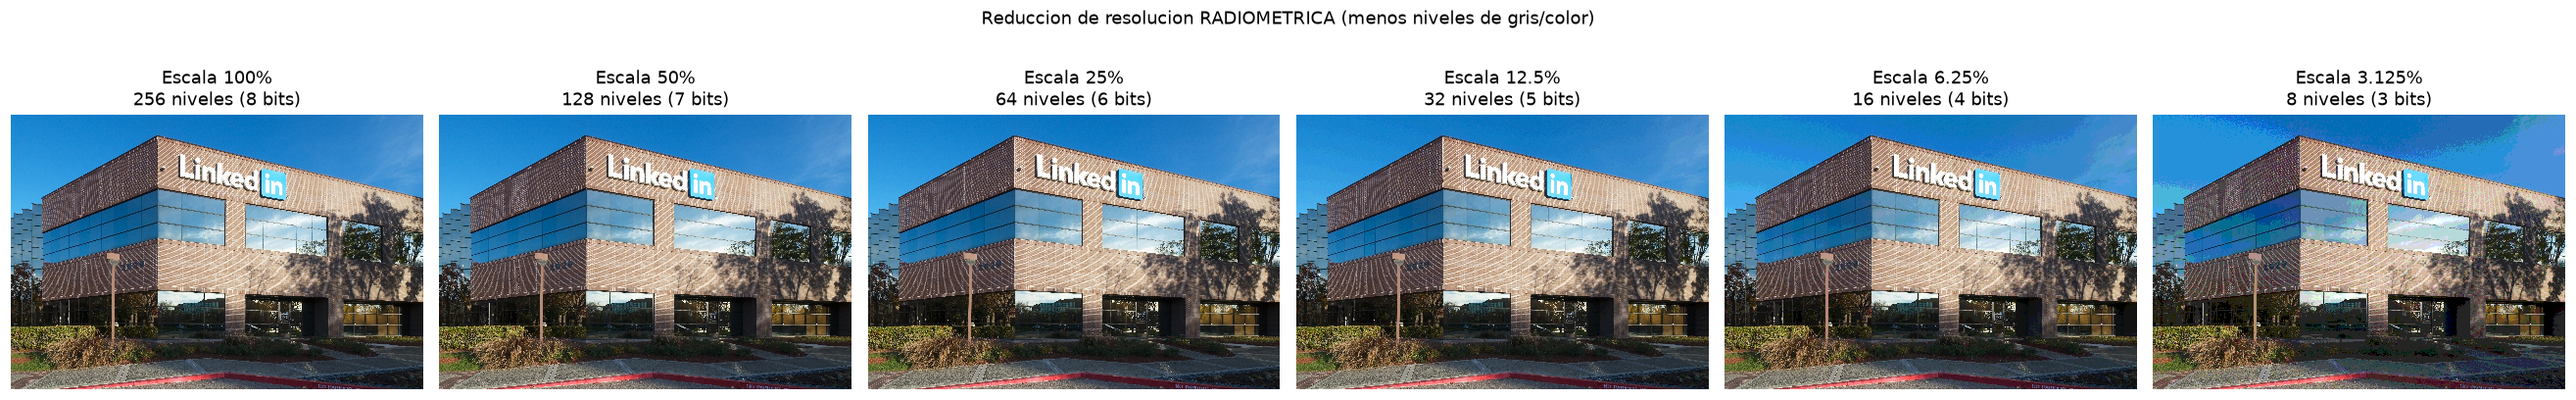

In [37]:
# Progresion a distintas escalas (% de los 256 niveles que se conservan)
ESCALAS_RADIO = [100, 50, 25, 12.5, 6.25, 3.125]

fig, axes = plt.subplots(1, len(ESCALAS_RADIO), figsize=(4 * len(ESCALAS_RADIO), 4))
for ax, e in zip(axes, ESCALAS_RADIO):
    n = niveles_desde_escala(e)
    red = reducir_radiometrica(img, e)
    if red.ndim == 2:
        ax.imshow(red, cmap="gray", vmin=0, vmax=255)
    else:
        ax.imshow(red)
    ax.set_title(f"Escala {e:g}%\n{n} niveles ({bits_de(n)} bits)"); ax.axis("off")
plt.suptitle("Reduccion de resolucion RADIOMETRICA (menos niveles de gris/color)", y=1.02)
plt.tight_layout(); plt.show()

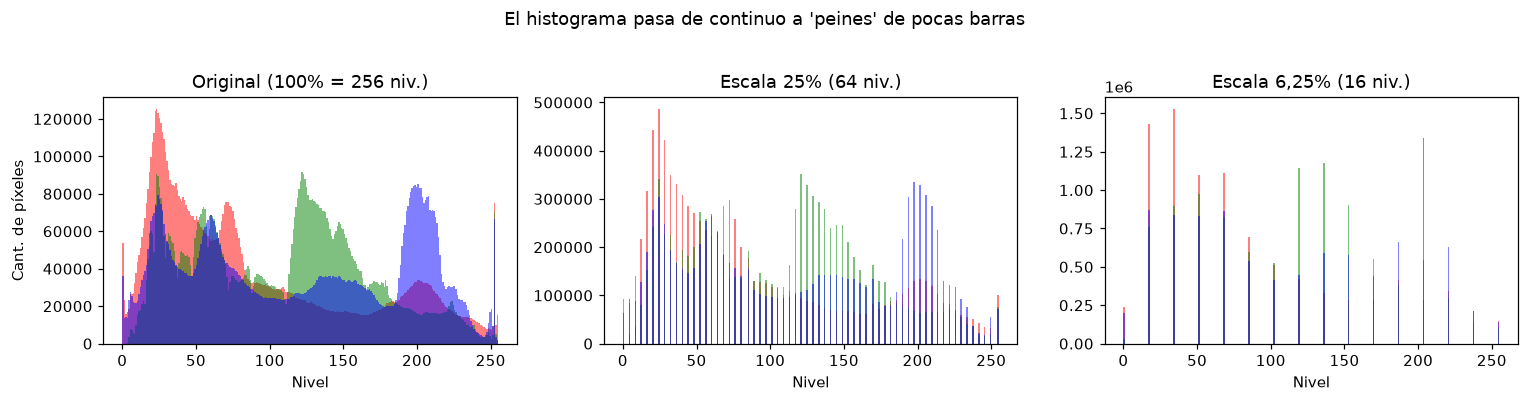

In [38]:
# Histograma
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
comparacion = [("Original (100% = 256 niv.)", img),
               ("Escala 25% (64 niv.)", img_25),
               ("Escala 6,25% (16 niv.)", img_6)]
for ax, (titulo, arr) in zip(axes, comparacion):
    if arr.ndim == 2:
        ax.hist(arr.ravel(), bins=256, range=(0, 255), color="gray")
    else:
        for i, c in enumerate(["red", "green", "blue"][:arr.shape[2]]):
            ax.hist(arr[:, :, i].ravel(), bins=256, range=(0, 255), color=c, alpha=0.5)
    ax.set_title(titulo); ax.set_xlabel("Nivel")
axes[0].set_ylabel("Cant. de píxeles")
plt.suptitle("El histograma pasa de continuo a 'peines' de pocas barras", y=1.03)
plt.tight_layout(); plt.show()

## 4. Guardar las salidas

Guardamos **exactamente lo mismo que muestran los gráficos**: la reducción radiométrica
**por canal** (`reducir_radiometrica`), pidiendo la **escala en %** y bajando a la mitad en
cada paso (50 % → 25 % → 12,5 % → … → 0,78125 %, es decir 128 → 64 → … → **2 niveles**,
1 bit por canal).

La tabla reporta la escala pedida, los **niveles reales por canal** (bajan a n) y el **tamaño
en disco** (se achica al haber menos información → menos niveles se guardan de verdad). En una
imagen color el PNG sigue siendo truecolor de 8 bits por canal (no admite menos sin pasar a
paleta), pero cada canal usa solo n niveles.

In [39]:
def a_pil(arr):
    """uint8 -> imagen PIL, respetando grises (2D) o color (3D)."""
    return Image.fromarray(arr) if arr.ndim == 3 else Image.fromarray(arr, mode="L")

def niveles_por_canal(arr):
    """Cantidad de niveles distintos que realmente usa cada canal."""
    if arr.ndim == 2:
        return [len(np.unique(arr))]
    return [len(np.unique(arr[:, :, c])) for c in range(arr.shape[2])]

# Guardamos LO MISMO que muestran los graficos, pidiendo la escala en %.
# Cada escala es la mitad de la anterior: 50% -> 128 niveles ... 0.78125% -> 2 niveles (1 bit).
ESCALAS_GUARDAR = [50, 25, 12.5, 6.25, 3.125, 1.5625, 0.78125]

print(f"{'escala':>9} | {'niveles':>7} | {'bits':>4} | {'niveles reales por canal':>26} | {'tamaño':>9}")
print("-" * 72)
for e in ESCALAS_GUARDAR:
    n = niveles_desde_escala(e)
    red = reducir_radiometrica(img, e)          # identico a lo que se ve en los graficos
    ruta = os.path.join(DIR_SALIDAS, f"radiometrica_{n:03d}niveles.png")
    a_pil(red).save(ruta)
    tam = os.path.getsize(ruta)
    print(f"{e:8g}% | {n:7d} | {bits_de(n):>4} | {str(niveles_por_canal(red)):>26} | {tam/1024:7.1f} KB")

# Guardamos tambien las reducciones espaciales (misma escala en %)
for e in [50, 25, 12.5, 2]:
    f = bloque_desde_escala(e)
    ruta = os.path.join(DIR_SALIDAS, f"espacial_bloque{f}x{f}.png")
    a_pil(reducir_espacial(img, e)).save(ruta)
    print(f"Guardada (escala {e:g}% -> bloque {f}x{f}): {ruta}")

print("\nLo guardado coincide con lo que muestran los graficos. Mínimo: 2 niveles/canal (1 bit).")

   escala | niveles | bits |   niveles reales por canal |    tamaño
------------------------------------------------------------------------
      50% |     128 |    7 |            [128, 128, 128] | 11007.3 KB
      25% |      64 |    6 |               [64, 64, 64] |  9226.1 KB
    12.5% |      32 |    5 |               [32, 32, 32] |  7379.2 KB
    6.25% |      16 |    4 |               [16, 16, 16] |  4479.1 KB
   3.125% |       8 |    3 |                  [8, 8, 8] |  3377.5 KB
  1.5625% |       4 |    2 |                  [4, 4, 4] |  1766.2 KB
 0.78125% |       2 |    1 |                  [2, 2, 2] |   862.0 KB
Guardada (escala 50% -> bloque 2x2): salidas/espacial_bloque2x2.png
Guardada (escala 25% -> bloque 4x4): salidas/espacial_bloque4x4.png
Guardada (escala 12.5% -> bloque 8x8): salidas/espacial_bloque8x8.png
Guardada (escala 2% -> bloque 50x50): salidas/espacial_bloque50x50.png

Lo guardado coincide con lo que muestran los graficos. Mínimo: 2 niveles/canal (1 bit).
